In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 20 13:52:44 2025

@author: aimee
"""

import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import csv
import netCDF4 as nc
from netCDF4 import Dataset

In this first block, the new altimetry data is read in and an ensemble is computed. 

Make sure to change the data directories!

In [2]:
datadir='/Users/aimee/Documents/collaborations/2026-IGCC-SLB/altimetry/'

datadir_TG='/Users/aimee/Documents/collaborations/2026-IGCC-SLB/TG/'

datadir_AR6='/Users/aimee/Documents/collaborations/2026-IGCC-SLB/AR6/'


In [3]:
#read AVISO data from text file
filename='MSL_Serie_MERGED_Global_AVISO_GIA_Adjust_Filter2m.txt'
f = open(datadir + filename, "r")
lines = f.readlines()
f.close()
ncols = 2  
nrows = len(lines)  
data = np.zeros([nrows, ncols])  
for jj in range(nrows):
    for ii in range(ncols):
        data[jj, ii] = float(lines[jj].split(" ")[ii])
        
time_AVISO = data[:,0]
series_AVISO = data[:,1]*1000 # data in m, convert to mm

In [4]:
#read NASA data from text file
filename='NASA_SSH_GMSL_INDICATOR.txt'
skip=1
f = open(datadir + filename, "r")
lines = [x.strip() for x in f.readlines()]
header = lines[skip - 1]
f.close()
ncols = 3  
nrows = len(lines) - skip  
data = np.zeros([nrows, ncols])  
for jj in range(nrows):
    for ii in range(ncols):
        data[jj, ii] = float(lines[jj + skip].split("    ")[ii])
        
time_NASA = data[:,0]
corr_NASA = -0.2434*data[:,0]+485.19   # correction for GIA based on previous year's NASA timeseries, in mm
series_NASA = (data[:,1]*10)-corr_NASA # data in cm, convert to mm, corrected for GIA

In [5]:
#read Uni_Colorado data from text file
filename='gmsl_2026rel1_seasons_rmvd.txt'
f = open(datadir + filename, "r")
lines = f.readlines()
f.close()
ncols = 2  
nrows = len(lines)  
data = np.zeros([nrows, ncols])  
for jj in range(nrows):
    for ii in range(ncols):
        data[jj, ii] = float(lines[jj].split(" ")[ii])
        
time_COL = data[:,0]
series_COL = data[:,1] # data in mm, no conversion needed

In [6]:
# compute annual means from satellite data & relate them to 1995-2014 mean & save in .csv file
SAT_ann = np.zeros([33,4])
ind1a = np.where((time_AVISO >= 1995.0) & (time_AVISO < 2015.0))[0]
ind2a = np.where((time_NASA >= 1995.0) & (time_NASA < 2015.0))[0]
ind3a = np.where((time_COL >= 1995.0) & (time_COL < 2015.0))[0]

for yy in range(33):
    SAT_ann[yy,0] = yy+1993.5
    #AVISO
    ind1 = np.where((time_AVISO >= yy+1993.0) & (time_AVISO < yy+1994.0))[0]
    SAT_ann[yy,1] = (series_AVISO[ind1].mean()) - (series_AVISO[ind1a].mean())
    #NASA
    ind2 = np.where((time_NASA >= yy+1993.0) & (time_NASA < yy+1994.0))[0]
    SAT_ann[yy,2] = (series_NASA[ind2].mean()) - (series_NASA[ind2a].mean())
    #COL
    ind3 = np.where((time_COL >= yy+1993.0) & (time_COL < yy+1994.0))[0]
    SAT_ann[yy,3] = (series_COL[ind3].mean()) - (series_COL[ind3a].mean())
    
# save data into a csv file
headers = ['year','AVISO', 'NASA','COLORADO']
with open('altimetry_indiv_estimates_93_25.csv','w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(headers)
    writer.writerows(SAT_ann)

In [7]:
# compute satellite ensemble mean and uncertainties & relate ensemble to 1995-2014 again & save in a .csv file
SAT_ens = np.zeros([33,3])
SAT_ens[:,0] = SAT_ann[:,0]
ind_mean = np.where((SAT_ann[:,0] >= 1995.0) & (SAT_ann[:,0] < 2015.0))[0]

for yy in range(33):
    SAT_ens[yy,1] = (SAT_ann[yy,1:4].mean()) #mean
    SAT_ens[yy,2] = np.std(SAT_ann[yy,1:4]) #1 std

check_mean = (SAT_ens[ind_mean,1].mean())#ensemble average for 1995-2014
SAT_ens[:,1]=SAT_ens[:,1]-check_mean

headers = ['year','mean', 'std']
with open('altimetry_ens_1993_2025.csv','w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(headers)
    writer.writerows(SAT_ens)

In this second part of the notebook, the new altimetry data is spliced to the IPCC ensemble in 1993.

First, define some functions. 

In [8]:
def read_tidegauge_gmsl(filename='AR6_GMSL_TG_ensemble_FGD.csv', key1='Central Estimate', 
                  key2='Total Unc. (1-sigma)\n', skip=2):
    """
    This function reads in the Ar6 tide gauge ensemble. 
    """
    f = open(datadir_AR6+filename, "r")
    lines = f.readlines()
    header = lines[skip - 1]
    keys = header.split(",")
    f.close()
    ncols = len(lines[-1].split(","))  
    nrows = len(lines) - skip  
    data = np.zeros([nrows, ncols])  
    for jj in range(nrows):
        for ii in range(ncols):
            data[jj, ii] = float(lines[jj + skip].split(",")[ii])
    data_dict = dict.fromkeys(keys)
    for kk, key in enumerate(keys):
        data_dict[key] = data[:, kk]
        
    yrs_tg = data_dict['Year']
    series_tg = data_dict[key1]
    error_tg  = data_dict[key2] #1 sigma error
        
    return yrs_tg, series_tg, error_tg

In [9]:
def read_altimeter_gmsl(filename='AR6_GMSL_altimeter_FGD.csv', key1='Central Estimate', 
                  key2='Uncertainty (1-sigma)\n', skip=2):
    """
    This function reads in the AR6 altimeter ensemble. 
    """
    f = open(datadir_AR6+filename, "r")
    lines = f.readlines()
    header = lines[skip - 1]
    keys = header.split(",")
    f.close()
    ncols = len(lines[-1].split(","))  
    nrows = len(lines) - skip  
    data = np.zeros([nrows, ncols])  
    for jj in range(nrows):
        for ii in range(ncols):
            data[jj, ii] = float(lines[jj + skip].split(",")[ii])
    data_dict = dict.fromkeys(keys)
    for kk, key in enumerate(keys):
        data_dict[key] = data[:, kk]
        
    yrs_2018 = data_dict['Year']
    mean_2018 = data_dict[key1]
    error_2018 = data_dict[key2] # 1-sigma error
   
    return yrs_2018, mean_2018, error_2018

In [10]:
def read_tidegauge_indiv(filename='AR6_GMSL_reconstructions_FGD.csv', key1='Year', 
                  key2='CW2011', key3='HA2015',key4='DA2017',key5='DA2019',key6='FR2020',
                  key7='CW2011unc', key8='HA2015unc',key9='DA2017unc',key10='DA2019unc' ,key11='FR2020unc', 
                  skip=2):
    """
    This function reads in the AR6 individual tide gauge time series. 
    """
    f = open(datadir_AR6+filename, "r")
    lines = f.readlines()
    header = lines[skip - 1]
    keys = header.split(",")
    f.close()
    ncols = len(lines[-1].split(","))  
    nrows = len(lines) - skip  
    data = np.zeros([nrows, ncols])  
    for jj in range(nrows):
        for ii in range(ncols):
            data[jj, ii] = float(lines[jj + skip].split(",")[ii])
    data_dict = dict.fromkeys(keys)
    for kk, key in enumerate(keys):
        data_dict[key] = data[:, kk]
        
    yrs_tg = data_dict['Year']
    CW2011 = data_dict[key2]
    HA2015 = data_dict[key3]
    DA2019 = data_dict[key5]
    FR2020 = data_dict[key6]
        
    return yrs_tg, CW2011, HA2015, DA2019, FR2020


In [11]:
def combine_TG_altimeter(tg_yrs, tg_series, tg_errors, alt_yrs, alt_series, alt_errors, fyr, lyr):
    """
    This function combines the tide gauge and altimeter timeseries and computes the 
    uncertainty in delta-GMSL relative to the first year of the timeseries. 
    """
    # Combined tide gauge and altimeter timeseries: 
    gmsl_yrs = np.arange(fyr, lyr+1, 1.0)
    gmsl_series = np.empty(len(gmsl_yrs))
    gmsl_errors = np.empty(len(gmsl_yrs))

    tmi = np.where((tg_yrs >= fyr) & (tg_yrs <= 1992.5))
    ami = np.where((alt_yrs >= 1993.5) & (alt_yrs <= lyr))
    gi1 = np.where((gmsl_yrs >= fyr ) & (gmsl_yrs <= 1992.5))
    gi2 = np.where((gmsl_yrs >= 1993.5) & (gmsl_yrs <= lyr))

    match_93 = tg_series[93]-alt_series[0] #connecting tg and altimetry in 1993

    gmsl_series[gi1] = tg_series[tmi]
    gmsl_series[gi2] = alt_series[ami]+match_93
    #compute gmsl_series relative to 1995-2014
    ind_mean = np.where((gmsl_yrs >= 1995.0) & (gmsl_yrs < 2015.0))[0] 
    check_mean = (gmsl_series[ind_mean].mean())#ensemble average for 1995-2014
    gmsl_series=gmsl_series-check_mean
    
    gmsl_errors[gi1] = tg_errors[tmi]
    gmsl_errors[gi2] = alt_errors[ami]
    
    # The delta error computes the total error in GMSL change for all timeseries points 
    # relative to the error in the first year (default = 1901). 
    delta_errors = gmsl_errors.copy()
    for ii in np.arange(len(gmsl_errors)):
        delta_errors[ii] = np.sqrt(np.square(delta_errors[0]) + np.square(delta_errors[ii]))
                              
    return gmsl_yrs, gmsl_series, gmsl_errors, delta_errors


In [12]:
def extract_core_period(yrs, series, errors, fyr, lyr):
    """
    This function extracts the core period as defined by fyr and lyr 
    """
    core_yrs = np.arange(fyr, lyr+1)
    core_series = np.zeros(len(core_yrs))
    core_errors = np.zeros(len(core_yrs))
    vals, ind1, ind2 = np.intersect1d(core_yrs, yrs, return_indices=True)
    core_series[ind1] = series[ind2]
    core_errors[ind1] = errors[ind2]
    return core_yrs, core_series, core_errors

Now, we use the AR6 tide gauge and altimetry data and combine them with the new altimetry data. 

In [13]:
#Read in the TG data from AR6
tg_yrs, tg_series, tg_errors = read_tidegauge_gmsl() #ensemble rel to 1995-2014
yrs_tg, CW2011, HA2015, DA2019, FR2020 = read_tidegauge_indiv() #individual TG, rel to 1995-2014

#Read in the Altimetry data from AR6 and compute combined time series to 2018
alt_yrs_2018, alt_series_2018, alt_errors_2018 = read_altimeter_gmsl() #relative to 1995-2014
gmsl_yrs_ipcc, gmsl_series_ipcc, gmsl_errors_ipcc, delta_errors_ipcc = combine_TG_altimeter(tg_yrs, tg_series, tg_errors, alt_yrs_2018, alt_series_2018, alt_errors_2018, 1901.5, 2018.5)#relative to 1995-2014

#Compute combined time series with AR6-TG up to 1993 and new altimetry from 1993 onwards
alt_yrs_2025, alt_series_2025, alt_errors_2025 = SAT_ens[:,0],SAT_ens[:,1],SAT_ens[:,2] #relative to 1995-2014
gmsl_yrs, gmsl_series, gmsl_errors, delta_errors = combine_TG_altimeter(tg_yrs, tg_series, tg_errors, alt_yrs_2025, alt_series_2025, alt_errors_2025, 1901.5, 2025.5)#relative to 1995-2014


In [14]:
#save gmsl data with AR6 TG to 1993 and new satellite data to 2025 as csv file
headers = ['year','mean', 'std']

final_series=np.zeros([125,3])
final_series[:,0]=gmsl_yrs
final_series[:,1]=gmsl_series
final_series[:,2]=delta_errors
with open('IGCC_2026_GMSL_ensemble_93_SAT.csv','w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(headers)        
    writer.writerows(final_series)

In [15]:
#Read new tide gauge reconstructions

#Wang 2024: https://journals.ametsoc.org/view/journals/clim/37/24/JCLI-D-23-0410.1.xml
filename='Wangetal2024_recons_gmsl_yr.txt'
f = open(datadir_TG + filename, "r")
lines = [x.strip() for x in f.readlines()]
f.close()
ncols = 3  
nrows = len(lines)  
data = np.zeros([nrows, ncols])  
for jj in range(nrows):
    for ii in range(ncols):
        data[jj, ii] = float(lines[jj].split("  ")[ii])
        
time_WANG = data[:,0]+0.5
series_WANG = np.zeros([120,2])
series_WANG[:,0] = data[:,1] # data in mm
ind4a = np.where((time_WANG >= 1995.0) & (time_WANG < 2015.0))[0]
for yy in range(120):
    series_WANG[yy,1] = (series_WANG[yy,0]) - (series_WANG[ind4a,0].mean()) #relative to 1995-2014


#Dangendorf 2024
ds = nc.Dataset(datadir_TG+'KalmanSmootherHR_Global.nc')
time_DANG = np.reshape(ds['t'][:]+0.5,(122,1))
series_DANG = np.zeros([122,2])
series_DANG[:,0] = ds['GMSLHR'][:]
ind5a = np.where((time_DANG >= 1995.0) & (time_DANG < 2015.0))[0]
for yy in range(122):
    series_DANG[yy,1] = ((series_DANG[yy,0]) - (series_DANG[ind5a,0].mean()))*1000 #relative to 1995-2014

#Mu 2025
ds2 = nc.Dataset(datadir_TG+'MU2025_SLRv2.nc')
time_MU = np.reshape(ds2['year'][:]+0.5,(123,1))
series_MU = np.zeros([123,2])
series_MU[:,0] = ds2['GMSL'][:]
ind6a = np.where((time_MU >= 1995.0) & (time_MU < 2015.0))[0] 
for yy in range(123):
    series_MU[yy,1] = ((series_MU[yy,0]) - (series_MU[ind6a,0].mean())) #relative to 1995-2014
    


In [16]:
#%% prepare Figure B & table values - rates & totals

# define different periods
fyr=[1971.5, 1971.5, 2006.5, 1976.5, 1986.5, 1996.5, 2006.5, 2016.5] 
lyr=[2018.5, 2006.5, 2018.5, 1995.5, 2005.5, 2015.5, 2025.5, 2025.5]

trends_fig = np.zeros([8, 4]) # this table contains the trends that are plotted in figure 13b
count=0

for jj in fyr:
    ii = float(lyr[count])
    if jj < 1993.5:
        # Read in TG timeseries for 1901-1993, from the combined timeseries
        sbyrs, sbseries, sberror = extract_core_period(tg_yrs, tg_series, tg_errors, fyr=jj, lyr=1993.5)
        del1 = sbseries[-1] - sbseries[0]
        err1 = np.sqrt(sberror[-1]**2 + sberror[0]**2) #1 sigma errors
        # Use altimeter timeseries for 1993 onwards
        sbyrs, sbseries, sberror = extract_core_period(alt_yrs_2025, alt_series_2025, alt_errors_2025, fyr=1993.5, lyr=ii)
        del2 = sbseries[-1] - sbseries[0]
        err2 = np.sqrt(sberror[-1]**2 + sberror[0]**2)
        # combine TG and altimetry 
        delta = del1 + del2
        error = np.sqrt(err1**2 + err2**2) #1 sigma errors               
        rate = delta/(ii-jj)
        rate_err = error/(ii-jj)

        trends_fig[count,:] = (jj, ii, rate, rate_err*1.645) #very likely range
        count = count+1    

    elif jj >= 1993.5: 
        # Use altimeter timeseries for 1993 onwards
        sbyrs, sbseries, sberror = extract_core_period(alt_yrs_2025, alt_series_2025, alt_errors_2025, fyr=jj, lyr=ii)
        del2 = sbseries[-1] - sbseries[0]
        err2 = np.sqrt(sberror[-1]**2 + sberror[0]**2)
        delta = del2
        error = err2       
        rate = delta/(ii-jj)
        rate_err = error/(ii-jj)
        
        trends_fig[count,:] = (jj, ii, rate, rate_err*1.645)#very likely range
        count = count+1

# For Table 11, compute trends & totals for IPCC periods (ending in 2018) & IGCC period (ending 2025)
# trends and total changes are on mid-point of the year!
# Note that IPCC numbers in Table 11 are from AR6 chapter 9. 

fyr_t=[1901.5, 1901.5, 1971.5, 1971.5, 1993.5, 1993.5, 2006.5, 2006.5, 2018.5] 
lyr_t=[2018.5, 2025.5, 2018.5, 2025.5, 2018.5, 2025.5, 2018.5, 2025.5, 2025.5]

trends = np.zeros([9, 5])
totals = np.zeros([9, 5])
count=0

for jj in fyr_t:
    ii = float(lyr_t[count])
    if jj < 1993.5:
        # Read in TG timeseries for 1901-1993, from the combined timeseries
        sbyrs, sbseries, sberror = extract_core_period(tg_yrs, tg_series, tg_errors, fyr=jj, lyr=1993.5)
        del1 = sbseries[-1] - sbseries[0]
        err1 = np.sqrt(sberror[-1]**2 + sberror[0]**2) #1 sigma errors
        # Use altimeter timeseries for 1993 onwards
        sbyrs, sbseries, sberror = extract_core_period(alt_yrs_2025, alt_series_2025, alt_errors_2025, fyr=1993.5, lyr=ii)
        del2 = sbseries[-1] - sbseries[0]
        err2 = np.sqrt(sberror[-1]**2 + sberror[0]**2)
        #combine errors    
        delta = del1 + del2
        error = np.sqrt(err1**2 + err2**2) #1 sigma errors   
        rate = delta/(ii-jj)
        rate_err = error/(ii-jj)
   
        totals [count,:] = (jj, ii, delta, delta-error*1.645, delta+error*1.645)
        trends[count,:] = (jj, ii, rate, rate-rate_err*1.645, rate+rate_err*1.645) #very likely range
        count = count+1

    elif jj >= 1993.5: 
        # Use altimeter timeseries for 1993 onwards
        sbyrs, sbseries, sberror = extract_core_period(alt_yrs_2025, alt_series_2025, alt_errors_2025, fyr=jj, lyr=ii)
        del2 = sbseries[-1] - sbseries[0]
        err2 = np.sqrt(sberror[-1]**2 + sberror[0]**2)
        
        delta = del2
        error = err2
        rate = delta/(ii-jj)
        rate_err = error/(ii-jj)
        
        totals [count,:] = (jj, ii, delta, delta - error*1.645, delta + error*1.645)
        trends[count,:] = (jj, ii, rate, rate-rate_err*1.645, rate+rate_err*1.645)#very likely range
        count = count+1

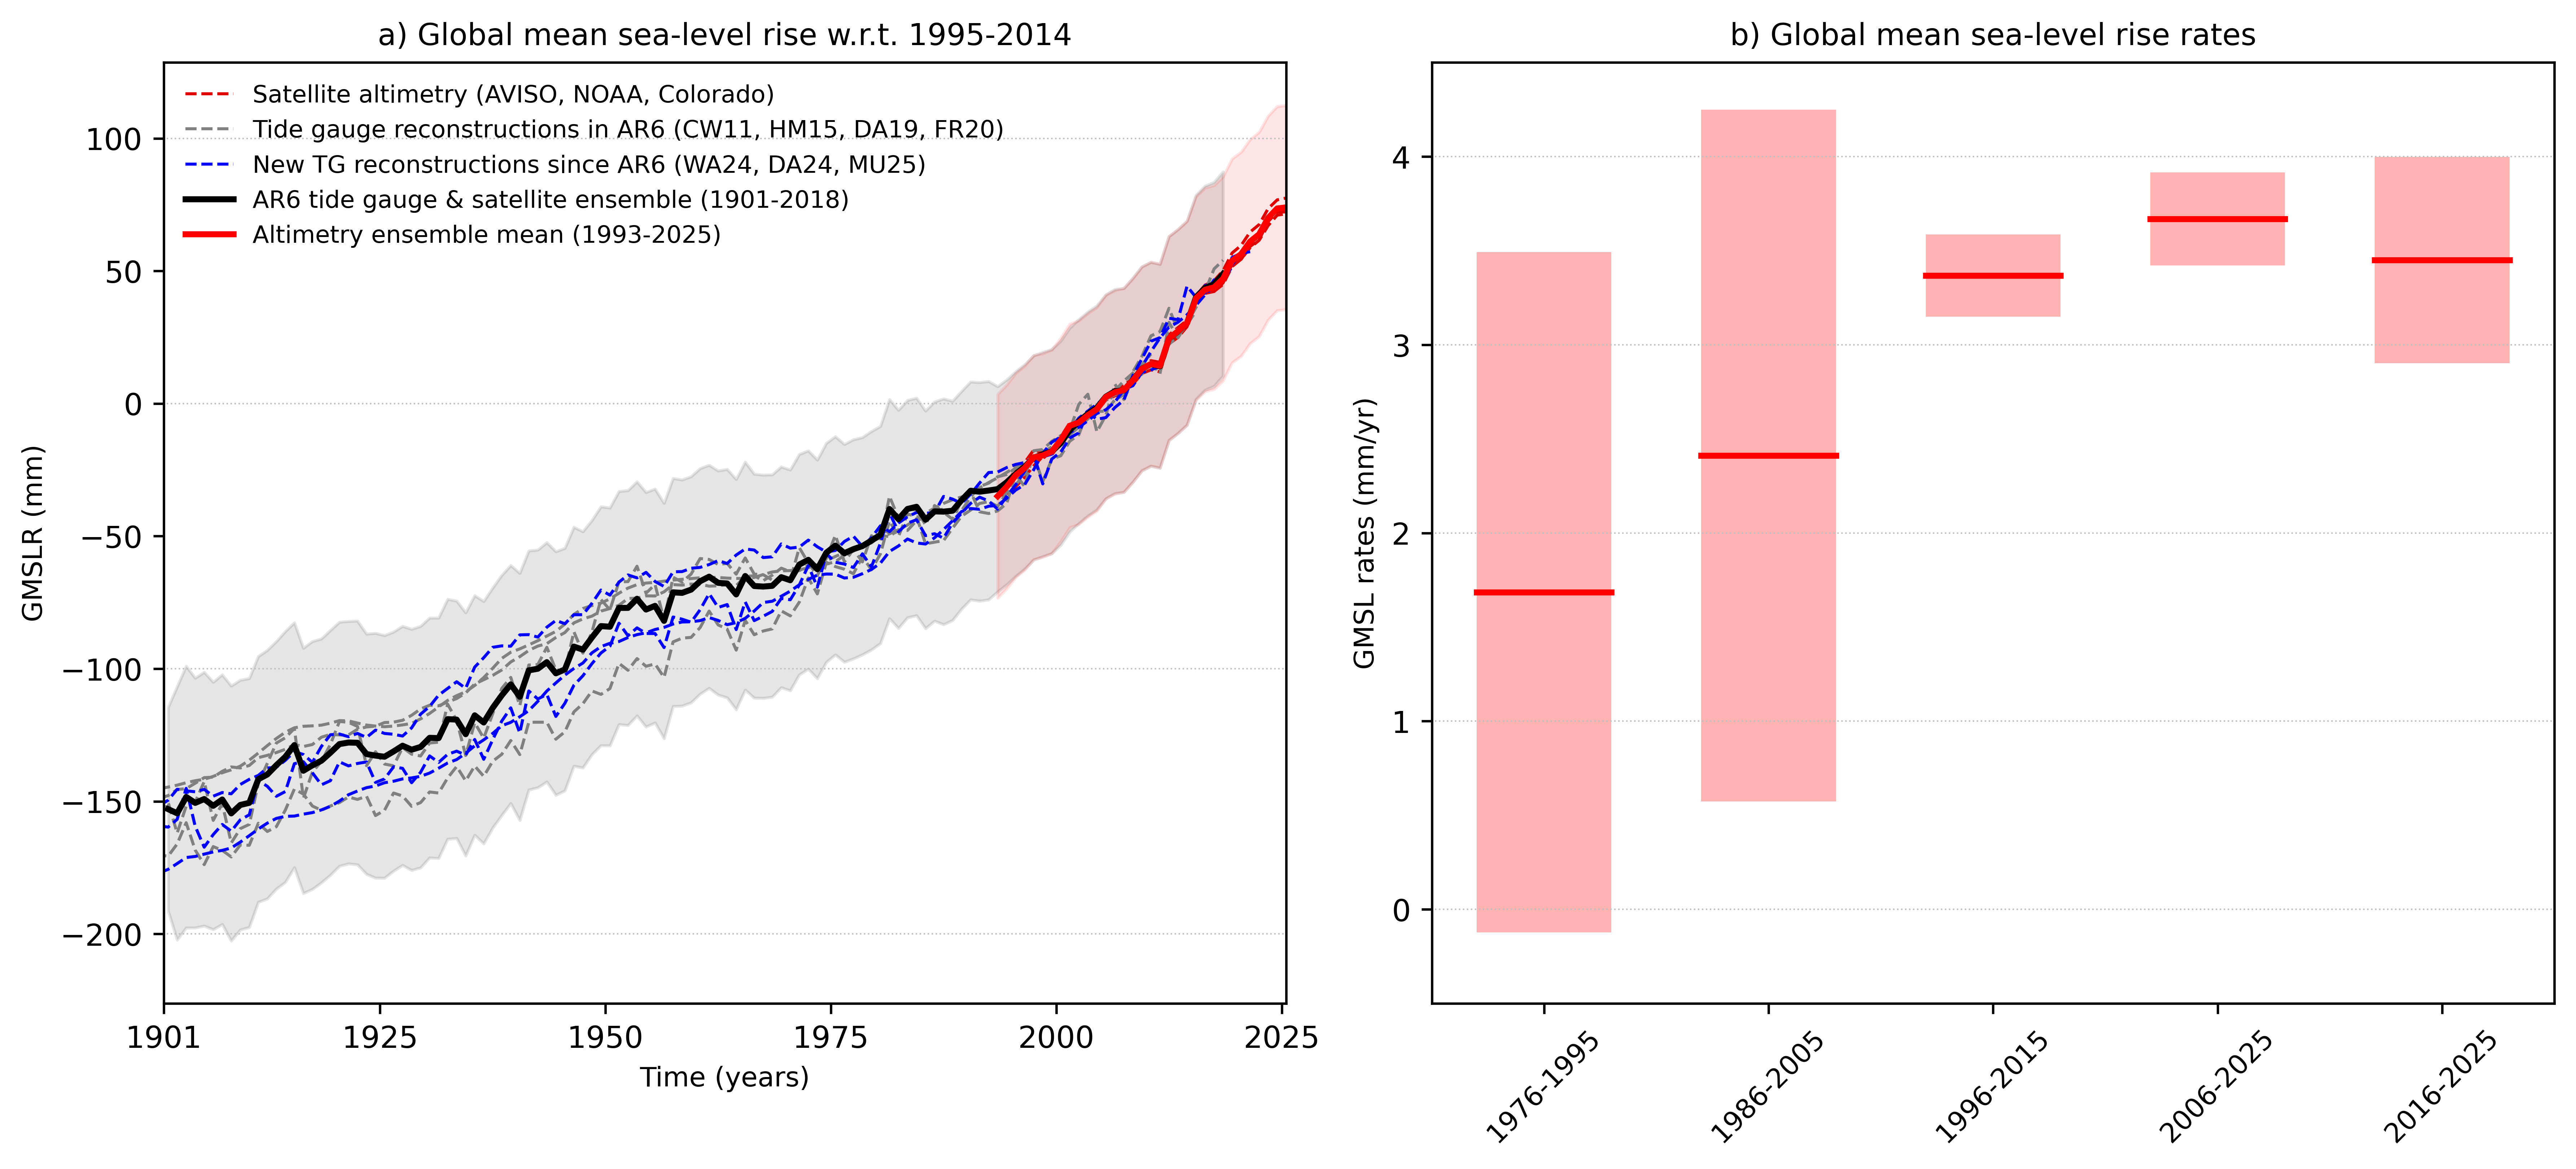

In [17]:
#%% plot Figure A - the combined timeseries
fig = plt.figure(dpi=600, figsize=(12,10))
ax=fig.add_subplot(2,2,1)
fs=8

## include grid lines
xmin, xmax = 1900, 2026
for val in [-200., -100., 0., 100.]:
    ax.plot([xmin, xmax],[val, val], color='silver', linestyle=':', linewidth=0.5)

##satellite indiv wrt 1995-2014
ax.plot(SAT_ann[:,0], SAT_ann[:,1], color="#df0000", linestyle='--',linewidth=1.0, label='Satellite altimetry (AVISO, NOAA, Colorado)')
ax.plot(SAT_ann[:,0], SAT_ann[:,2], color="#df0000", linestyle='--',linewidth=1.0)
ax.plot(SAT_ann[:,0], SAT_ann[:,3], color="#df0000", linestyle='--',linewidth=1.0)

#tg indiv wrt 1995-2014
ax.plot(yrs_tg, CW2011, color='grey', linestyle = '--', linewidth=1.0, label='Tide gauge reconstructions in AR6 (CW11, HM15, DA19, FR20)')
ax.plot(yrs_tg, HA2015, color='grey', linestyle = '--', linewidth=1.0)
ax.plot(yrs_tg, DA2019, color='grey', linestyle = '--', linewidth=1.0)
ax.plot(yrs_tg, FR2020, color='grey', linestyle = '--', linewidth=1.0)

#new TG reconstructions since ar6 wrt 1995-2014
ax.plot(time_WANG, series_WANG[:,1], color='blue', linestyle = '--', linewidth=1.0, label='New TG reconstructions since AR6 (WA24, DA24, MU25)')
ax.plot(time_DANG, series_DANG[:,1], color='blue', linestyle = '--', linewidth=1.0)
ax.plot(time_MU, series_MU[:,1], color='blue', linestyle = '--', linewidth=1.0)

#ipcc ensemble & errors wrt 1995-2014
ax.plot(gmsl_yrs_ipcc, gmsl_series_ipcc,'k' ,linewidth=2.0, label='AR6 tide gauge & satellite ensemble (1901-2018)')
ax.fill_between(gmsl_yrs_ipcc,(gmsl_series_ipcc-delta_errors_ipcc),(gmsl_series_ipcc+delta_errors_ipcc),color='k',alpha=0.1) # 1 sigma errors

#add altimetry ensemble wrt 1995-2014
ax.plot(gmsl_yrs[92:125], gmsl_series[92:125],'r' ,linewidth=2.0, label='Altimetry ensemble mean (1993-2025)')
ax.fill_between(gmsl_yrs[92:125],(gmsl_series[92:125]-delta_errors[92:125]),(gmsl_series[92:125]+delta_errors[92:125]),color='r',alpha=0.1) # 1 sigma errors

#making the plot pretty
ax.set_title('a) Global mean sea-level rise w.r.t. 1995-2014', fontsize=fs+2)
ax.legend(loc='upper left', fontsize=fs, frameon=False)
ax.set_ylabel('GMSLR (mm)', fontsize=fs+1)
ax.set_xlabel('Time (years)', fontsize=fs+1)
ax.set_xlim(1901.5, 2025.5)
ax.set_xticks([1901, 1925, 1950, 1975,2000, 2025])


# plotting FIGURE B - error bar trend figure
ax2=fig.add_subplot(2,2,2)
fs=8
alpha = 0.3

fyr=[1976.5, 1986.5, 1996.5, 2006.5, 2016.5] 
lyr=[1995.5, 2005.5, 2015.5, 2025.5, 2025.5]

# Central estimates and +/- error for very likely ranges
IGCC_dict = {'1976-1995':[trends_fig[3,2],trends_fig[3,3]],
            '1986-2005':[trends_fig[4,2],trends_fig[4,3]],
            '1996-2015':[trends_fig[5,2],trends_fig[5,3]], 
            '2006-2025':[trends_fig[6,2],trends_fig[6,3]], 
            '2016-2025':[trends_fig[7,2],trends_fig[7,3]]}

labels=[] # Define an empty list for year labels

for ss, syr in enumerate(fyr):
    xpts = [ss-0.3, ss+0.3]
    eyr = lyr[ss]
    label = str(int(syr-0.5)) + '-' + str(int(eyr-0.5))
    labels.append(label)
    delta, error = IGCC_dict[str(int(syr-0.5))+'-'+str(int(eyr-0.5))]
    ax2.fill_between(xpts, delta-error, delta+error, facecolor='red', alpha=alpha)
    ax2.plot(xpts, [delta, delta], linewidth=2.0, linestyle='-', color='red')

#making the plot pretty
xmin, xmax = -1, 9
for val in [-2., -1., 0., 1., 2.,3., 4., 5. ]:
    ax2.plot([xmin, xmax],[val, val], color='silver', linestyle=':', linewidth=0.5)
ax2.set_title('b) Global mean sea-level rise rates', fontsize=fs+2)
ax2.set_ylabel('GMSL rates (mm/yr)', fontsize=fs+1)
ax2.set_ylim(-0.5, 4.5)
ax2.set_xlim(-0.5, 4.5)
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_xticklabels(labels,rotation=45, fontsize=fs+1)


#SAVING THE FIGURE
fig.tight_layout()
fig.savefig('SLC_figAB_IGCC26_NEWSAT.png', bbox_inches='tight')
